<a href="https://colab.research.google.com/github/jkrish006/Pandas_case_study/blob/main/Supervised_Learning_Casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
telecom=pd.read_csv("/content/Training_data.csv")
telecom.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [6]:
telecom.shape

(5634, 21)

In [7]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [8]:
telecom.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [9]:
telecom.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [10]:
telecom["gender"]=telecom["gender"].fillna(telecom["gender"].mode()[0])

In [11]:
telecom["gender"].value_counts()

,count
gender,
Male,2913
Female,2721


In [12]:
telecom["OnlineSecurity"]=telecom["OnlineSecurity"].fillna(telecom["OnlineSecurity"].mode()[0])

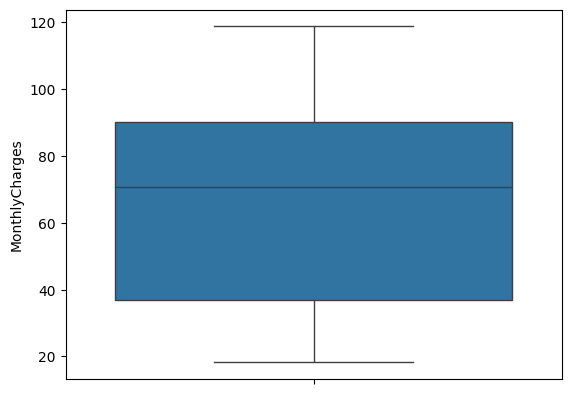

In [13]:
sns.boxplot(y=telecom["MonthlyCharges"])
plt.show()

In [14]:
telecom["MonthlyCharges"]=telecom["MonthlyCharges"].fillna(telecom["MonthlyCharges"].mean())

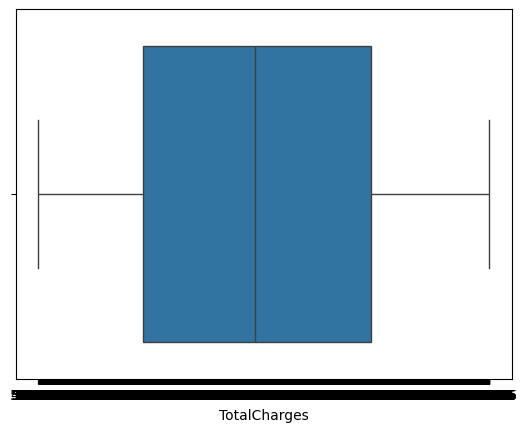

In [15]:
sns.boxplot(x=telecom["TotalCharges"])
plt.show()

In [16]:
telecom["TotalCharges"] = pd.to_numeric(telecom["TotalCharges"], errors='coerce')
telecom["TotalCharges"]=telecom["TotalCharges"].fillna(telecom["TotalCharges"].median())

In [17]:
telecom.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [18]:
telecom.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.159744,32.606851,65.102052,2238.250728
std,0.366401,24.614976,28.986241,2216.294428
min,0.000000,0.000000,18.250000,18.850000
25%,0.000000,9.000000,44.000000,446.062500
50%,0.000000,29.000000,68.925000,1396.450000
75%,0.000000,56.000000,89.100000,3590.537500
max,1.000000,72.000000,118.750000,8684.800000


In [19]:
telecom.duplicated().sum()

np.int64(0)

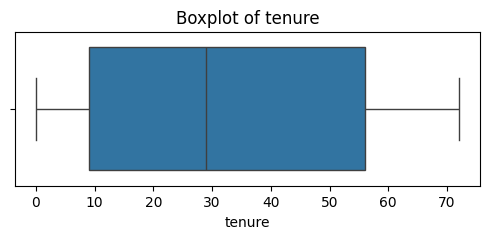

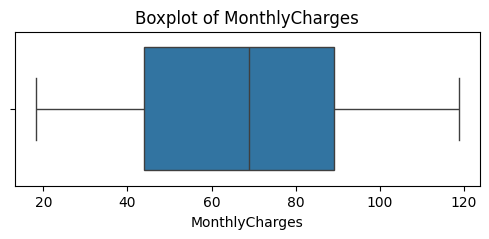

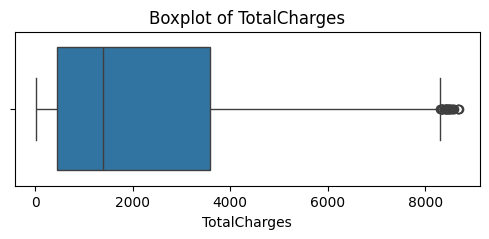

In [20]:
numeric_cols=["tenure","MonthlyCharges","TotalCharges"]
for i in numeric_cols:
  plt.figure(figsize=(6,2))
  sns.boxplot(x=telecom[i])
  plt.title(f"Boxplot of {i}")
  plt.show()

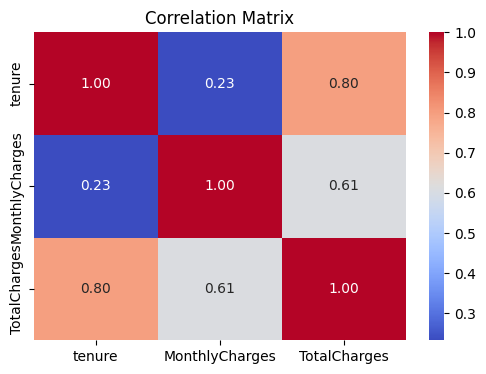

In [21]:
plt.figure(figsize=(6, 4))
sns.heatmap(telecom[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [22]:
telecom.drop(columns=['customerID'],inplace=True)

In [23]:
from sklearn.model_selection import train_test_split
y = telecom['Churn']
X = telecom.drop(columns='Churn')
obj_cols = X.select_dtypes(include='object').columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = pd.get_dummies(X_train, columns=obj_cols, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=obj_cols, drop_first=True, dtype=int)

In [24]:
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4082,0,50,108.25,5431.40,1,1,1,1,0,1,...,0,1,0,1,1,0,1,0,1,0
1728,1,9,49.20,447.90,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2795,0,3,97.90,315.30,0,0,0,1,0,0,...,0,1,0,1,0,0,1,0,1,0
334,0,36,20.35,695.85,1,0,0,1,0,0,...,1,0,1,0,1,0,1,1,0,0
3625,1,30,40.30,1172.95,0,0,0,0,1,0,...,0,1,0,0,0,0,1,0,1,0


In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4082,0,0.709857,1.496561,1.460839,1,1,1,1,0,1,...,0,1,0,1,1,0,1,0,1,0
1728,1,-0.957030,-0.538916,-0.803056,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2795,0,-1.200965,1.139793,-0.863293,0,0,0,1,0,0,...,0,1,0,1,0,0,1,0,1,0
334,0,0.140676,-1.533387,-0.690418,1,0,0,1,0,0,...,1,0,1,0,1,0,1,1,0,0
3625,1,-0.103259,-0.845703,-0.473682,0,0,0,0,1,0,...,0,1,0,0,0,0,1,0,1,0


Feature engineer



In [26]:
X_train["CLV"] = X_train["tenure"] * X_train["MonthlyCharges"]
X_test["CLV"] = X_test["tenure"] * X_test["MonthlyCharges"]

In [27]:
X_train["Tenure_OneYear"] = X_train["tenure"] * X_train["Contract_One year"]
X_train["Tenure_TwoYear"] = X_train["tenure"] * X_train["Contract_Two year"]

X_test["Tenure_OneYear"] = X_test["tenure"] * X_test["Contract_One year"]
X_test["Tenure_TwoYear"] = X_test["tenure"] * X_test["Contract_Two year"]

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
import pandas as pd

feature_importance = pd.DataFrame({"Feature": X_train.columns,"Importance": rf.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
feature_importance.head(10)

,Feature,Importance
30,CLV,0.152724
3,TotalCharges,0.139285
1,tenure,0.132505
2,MonthlyCharges,0.118587
10,InternetService_Fiber optic,0.040516
28,PaymentMethod_Electronic check,0.036197
32,Tenure_TwoYear,0.026068
4,gender_Male,0.024688
25,Contract_Two year,0.022535
31,Tenure_OneYear,0.021735


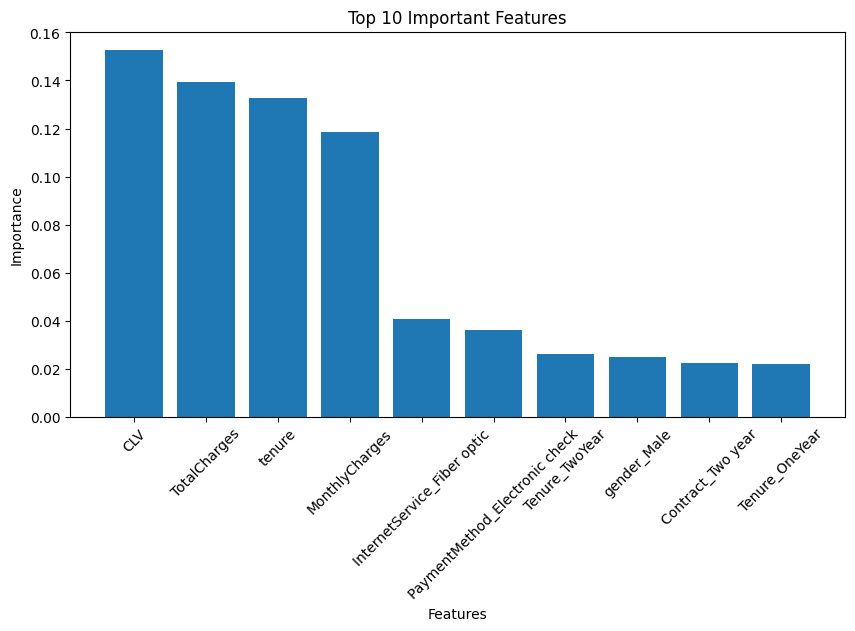

In [30]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["Feature"], top10["Importance"])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top 10 Important Features")
plt.show()

In [31]:
from sklearn.linear_model import LogisticRegression

lg_model=LogisticRegression(class_weight="balanced")
lg_model.fit(X_train,y_train)
y_pred=lg_model.predict(X_test)
y_pred

array(['No', 'No', 'Yes', ..., 'Yes', 'Yes', 'No'], dtype=object)

In [32]:
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7409050576752441

Classification Report:
               precision    recall  f1-score   support

          No       0.90      0.71      0.80       803
         Yes       0.53      0.81      0.64       324

    accuracy                           0.74      1127
   macro avg       0.72      0.76      0.72      1127
weighted avg       0.80      0.74      0.75      1127



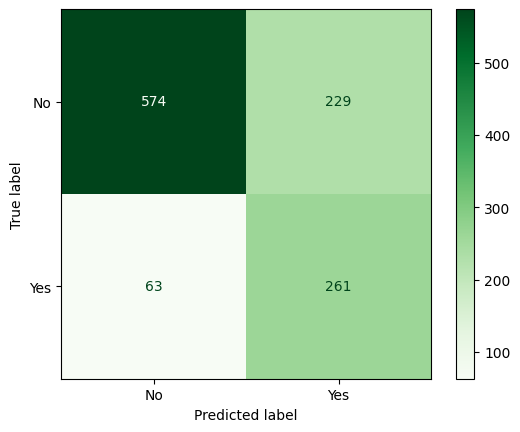

In [33]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap="Greens")
plt.show()

In [34]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=5,
    max_leaf_nodes=5,
    class_weight="balanced"
)
dt_model.fit(X_train,y_train)
y_pred_dt=dt_model.predict(X_test)
print(accuracy_score(y_test,y_pred_dt))

0.7329192546583851


In [35]:
model_rf = RandomForestClassifier(
    random_state=30,
    n_estimators=200,
    max_depth=10,
    min_samples_split=15,
    max_features="sqrt",
    class_weight=None
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print(accuracy_score(y_test, y_pred_rf))

0.7888198757763976


In [36]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [ 'sqrt', 'log2'],
}

grid_search = GridSearchCV(
    estimator=model_rf,
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

grid_search.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'n_estimators': 200}

In [38]:
grid_search.best_score_
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(accuracy_score(y_test, y_pred_best))

0.7843833185448092


Test


In [42]:
test_data = pd.read_csv("/content/Testing_data.csv")

test_data.drop("customerID", axis=1, inplace=True)
test_data["TotalCharges"] = pd.to_numeric(test_data["TotalCharges"], errors="coerce")
test_data["TotalCharges"].fillna(test_data["TotalCharges"].median(), inplace=True)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
test_data["Churn"] = le.fit_transform(test_data["Churn"])

X_test = test_data.drop("Churn", axis=1)
y_test = test_data["Churn"]

test_encoded = pd.get_dummies(
    X_test,
    columns=obj_cols,
    drop_first=True,
    dtype=int
)

test_encoded = test_encoded.reindex(columns=X_train.columns, fill_value=0)

predictions = best_model.predict(test_encoded)

/tmp/ipykernel_846/2532592017.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data["TotalCharges"].fillna(test_data["TotalCharges"].median(), inplace=True)


In [43]:
test_encoded = pd.get_dummies(
    X_test,
    columns=obj_cols,
    drop_first=True,
    dtype=int
)

test_encoded = test_encoded.reindex(columns=X_train.columns, fill_value=0)

In [44]:
X_test['TotalCharges'] = pd.to_numeric(X_test['TotalCharges'], errors='coerce')
X_test['TotalCharges'] = X_test['TotalCharges'].fillna(X_test['TotalCharges'].median())

In [45]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [50]:
X_test["CLV"] = X_test["tenure"] * X_test["MonthlyCharges"]

X_test["Tenure_OneYear"] = X_test["tenure"] * X_test["Contract_One year"]
X_test["Tenure_TwoYear"] = X_test["tenure"] * X_test["Contract_Two year"]

In [52]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [53]:
predictions = best_model.predict(X_test)

In [56]:
y_pred = lg_model.predict(X_test)

In [59]:
y_pred = pd.Series(y_pred).map({'No': 0, 'Yes': 1})

In [60]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.6721078779276083

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.66      0.75      1044
           1       0.42      0.72      0.53       365

    accuracy                           0.67      1409
   macro avg       0.65      0.69      0.64      1409
weighted avg       0.75      0.67      0.69      1409


Confusion Matrix

[[685 359]
 [103 262]]
